In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer

try:
    from wordcloud import WordCloud
except ImportError:
    !pip install wordcloud
    from wordcloud import WordCloud

In [9]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /home/e0de8c06-33ac-4d51-9c9b-
[nltk_data]     553d4cac7da1/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/e0de8c06-33ac-4d51-9c9b-
[nltk_data]     553d4cac7da1/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/e0de8c06-33ac-4d51-9c9b-
[nltk_data]     553d4cac7da1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/e0de8c06-33ac-4d51-9c9b-
[nltk_data]     553d4cac7da1/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
df = pd.read_csv('simple_dataset.csv')
print(df.head())

   category                                               text
0  Positive  I love this product! It works great and has ex...
1  Negative  Terrible experience. The product broke after o...
2  Positive  Fantastic! I would highly recommend this to ev...
3  Negative           Awful. It was a complete waste of money.
4  Positive  Amazing product! Very satisfied with my purchase.


In [11]:
def preprocess_review(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = nltk.word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return ' '.join(lemmatized_tokens)

In [12]:
df['preprocessed_text'] = df['text'].apply(preprocess_review)
print(df)

   category                                               text  \
0  Positive  I love this product! It works great and has ex...   
1  Negative  Terrible experience. The product broke after o...   
2  Positive  Fantastic! I would highly recommend this to ev...   
3  Negative           Awful. It was a complete waste of money.   
4  Positive  Amazing product! Very satisfied with my purchase.   
5  Negative        Do not buy this. It is not worth the price.   

                           preprocessed_text  
0  love product work great excellent quality  
1  terrible experience product broke one use  
2  fantastic would highly recommend everyone  
3                 awful complete waste money  
4         amazing product satisfied purchase  
5                            buy worth price  


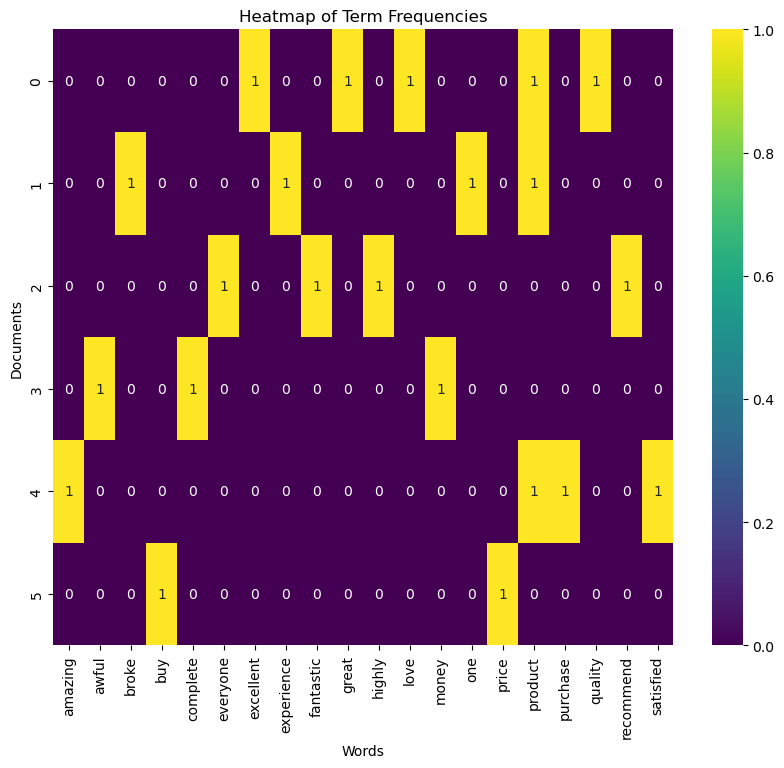

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# Convert text to matrix
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])

# Convert to array
term_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(term_matrix, xticklabels=terms, cmap='viridis', annot=True)

plt.title("Heatmap of Term Frequencies")
plt.xlabel("Words")
plt.ylabel("Documents")

plt.show()

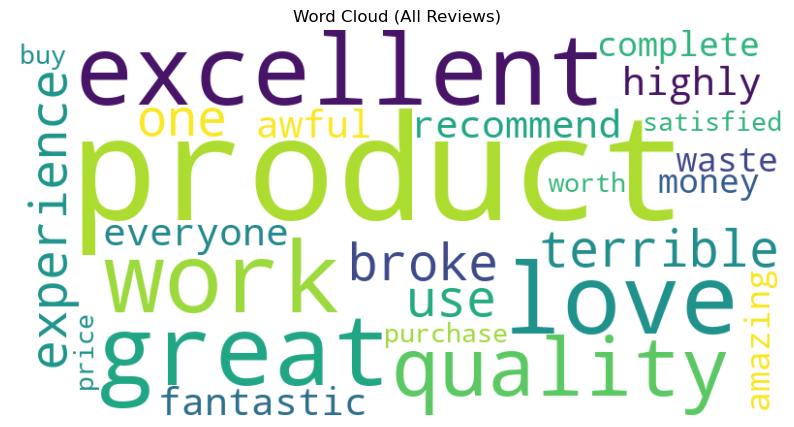

In [14]:
from wordcloud import WordCloud

all_text = " ".join(df['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (All Reviews)")
plt.show()

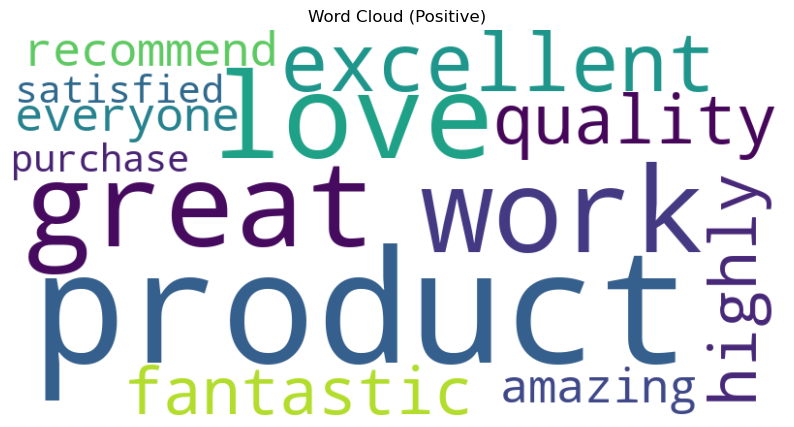

In [15]:
positive_text = " ".join(df[df['category'] == 'Positive']['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (Positive)")
plt.show()

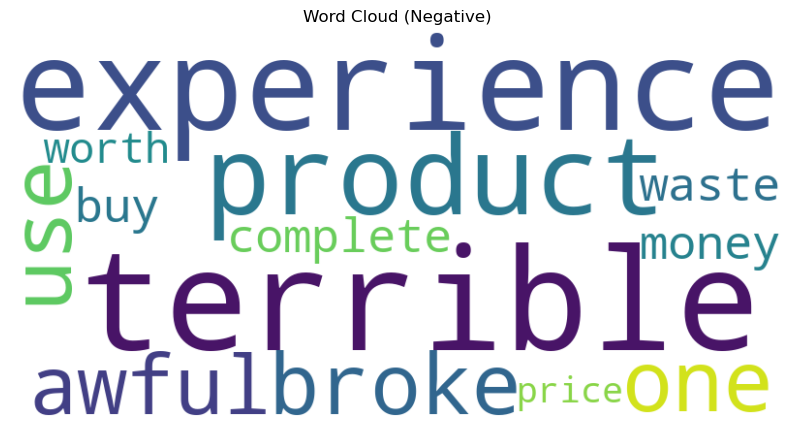

In [16]:
negative_text = " ".join(df[df['category'] == 'Negative']['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud (Negative)")
plt.show()

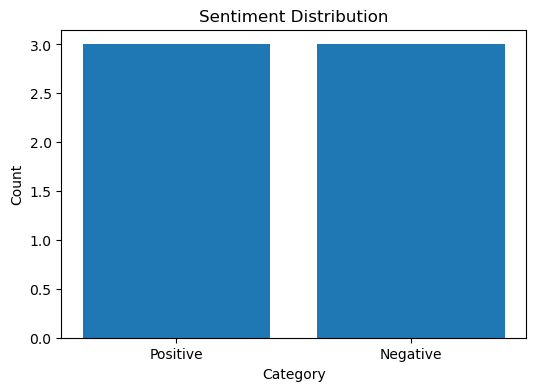

In [17]:
counts = df['category'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [18]:
print(df['category'].value_counts())

category
Positive    3
Negative    3
Name: count, dtype: int64
